In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
# Load datasets

fund_master = pd.read_csv("data/processed/01_fund_master_cleaned.csv")
nav_history = pd.read_csv("data/processed/02_nav_history_cleaned.csv")
aum = pd.read_csv("data/processed/03_aum_by_fund_house_cleaned.csv")
sip = pd.read_csv("data/processed/04_monthly_sip_inflows_cleaned.csv")
category = pd.read_csv("data/processed/05_category_inflows_cleaned.csv")
folio = pd.read_csv("data/processed/06_industry_folio_count_cleaned.csv")
performance = pd.read_csv("data/processed/07_scheme_performance_cleaned.csv")
transactions = pd.read_csv("data/processed/08_investor_transactions_cleaned.csv")
portfolio = pd.read_csv("data/processed/09_portfolio_holdings_cleaned.csv")
benchmark = pd.read_csv("data/processed/10_benchmark_indices_cleaned.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


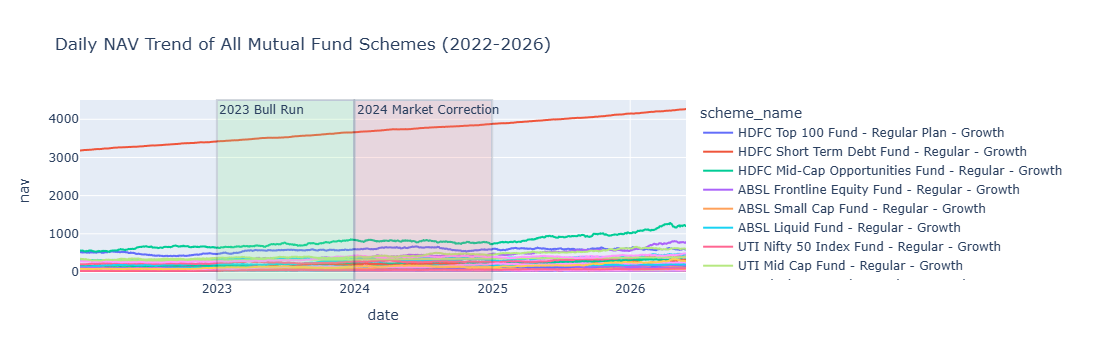

In [3]:
# Chart 1 - NAV Trend Analysis

import plotly.express as px

# Convert date column
nav_history["date"] = pd.to_datetime(nav_history["date"])

# Merge scheme names
nav_data = nav_history.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

fig = px.line(
    nav_data,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of All Mutual Fund Schemes (2022-2026)"
)

# Highlight Bull Run (2023)
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="lightgreen",
    opacity=0.2,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight Market Correction (2024)
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="lightcoral",
    opacity=0.2,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

fig.show()

In [4]:
print(aum.columns)

print("\nShape:")
print(aum.shape)

print("\nFirst 5 rows:")
print(aum.head())

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

Shape:
(90, 5)

First 5 rows:
         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168


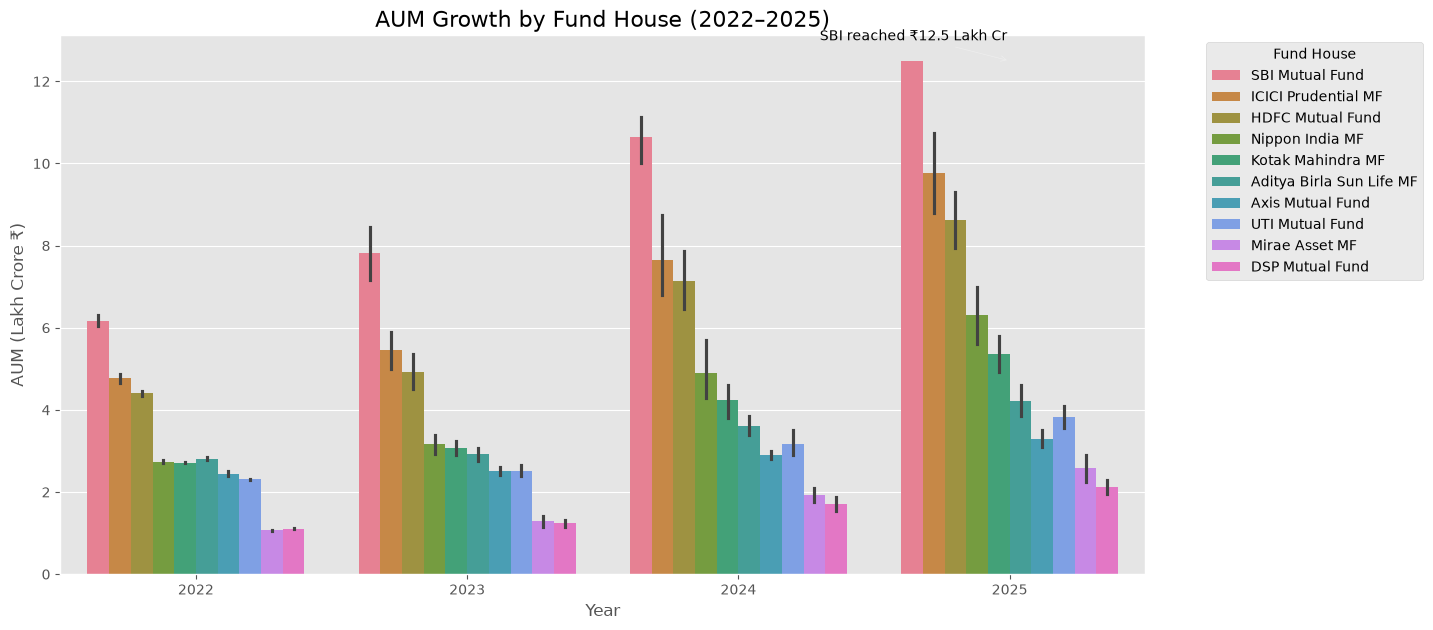

Chart saved successfully!


In [5]:
# Chart 2 - AUM Growth by Fund House

import seaborn as sns
import matplotlib.pyplot as plt

# Convert date column to datetime
aum["date"] = pd.to_datetime(aum["date"])

# Extract year
aum["year"] = aum["date"].dt.year

# Create chart
plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

# Title and labels
plt.title("AUM Growth by Fund House (2022–2025)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore ₹)")

# Highlight SBI dominance
plt.annotate(
    "SBI reached ₹12.5 Lakh Cr",
    xy=(3,12.5),
    xytext=(2.3,13),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

plt.legend(title="Fund House", bbox_to_anchor=(1.05,1), loc="upper left")

# Save chart
plt.savefig("charts/Chart2_AUM_Growth.png", dpi=300, bbox_inches="tight")

plt.show()

print("Chart saved successfully!")

In [6]:
print(sip.columns)

print("\nShape:")
print(sip.shape)

print("\nFirst 5 rows:")
print(sip.head())

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

Shape:
(48, 6)

First 5 rows:
     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  


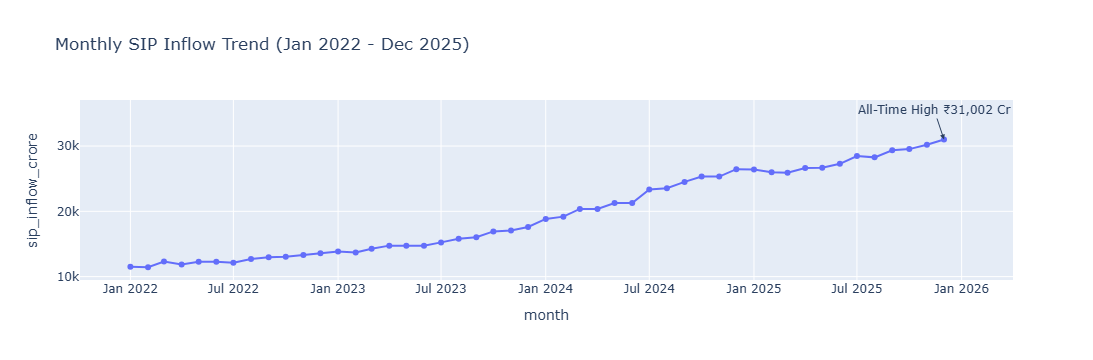

In [9]:
# Chart 3 - Monthly SIP Inflow Trend

import plotly.express as px

# Convert month column to datetime
sip["month"] = pd.to_datetime(sip["month"])

# Create line chart
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)"
)

# Highlight highest SIP inflow (₹31,002 Cr in Dec 2025)
fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="All-Time High ₹31,002 Cr",
    showarrow=True,
    arrowhead=2
)

fig.show()

In [10]:
fig.write_image("charts/Chart3_SIP_Inflow_Trend.png")

print("Chart saved successfully!")

Chart saved successfully!


In [11]:
print(category.columns)

print("\nShape:")
print(category.shape)

print("\nFirst 5 rows:")
print(category.head())

Index(['month', 'category', 'net_inflow_crore'], dtype='str')

Shape:
(144, 3)

First 5 rows:
     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0


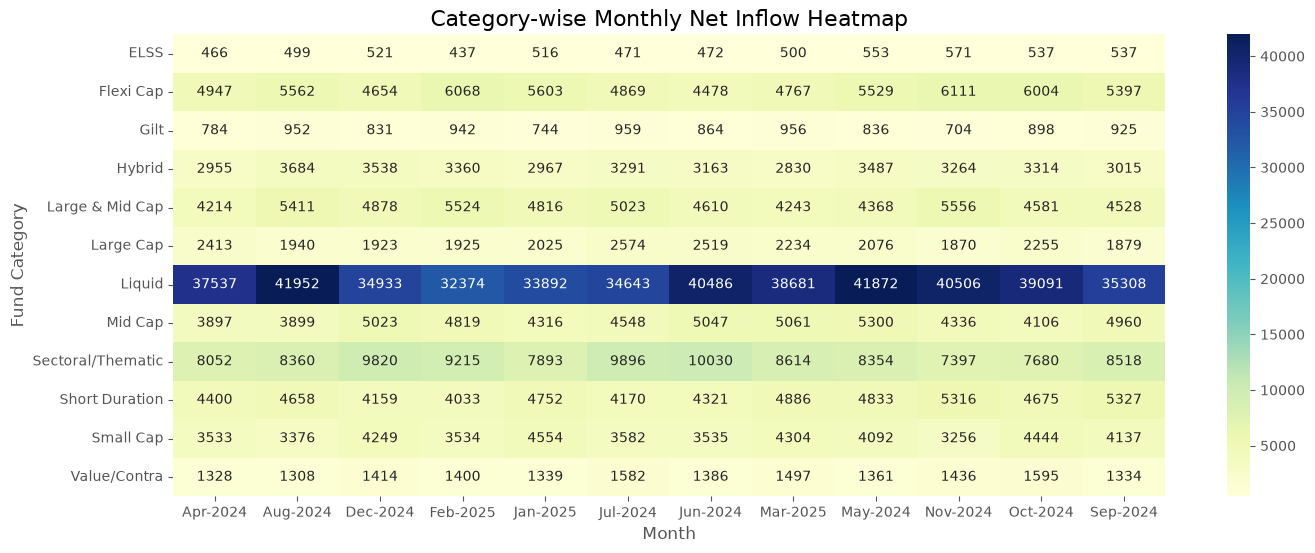

Chart 4 saved successfully!


In [12]:
# Chart 4 - Category Inflow Heatmap

import seaborn as sns
import matplotlib.pyplot as plt

# Convert month to datetime
category["month"] = pd.to_datetime(category["month"])

# Convert month into Month-Year format
category["month"] = category["month"].dt.strftime("%b-%Y")

# Create pivot table
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

# Plot heatmap
plt.figure(figsize=(16,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f"
)

plt.title("Category-wise Monthly Net Inflow Heatmap", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Fund Category")

# Save chart
plt.savefig("charts/Chart4_Category_Heatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

print("Chart 4 saved successfully!")

In [13]:
print(transactions.columns)

print("\nShape:")
print(transactions.shape)

print("\nFirst 5 rows:")
print(transactions.head())

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

Shape:
(32778, 13)

First 5 rows:
  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              Sip        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              Sip         912   
3   INV003436       2024-01-01     118634              Sip        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male        

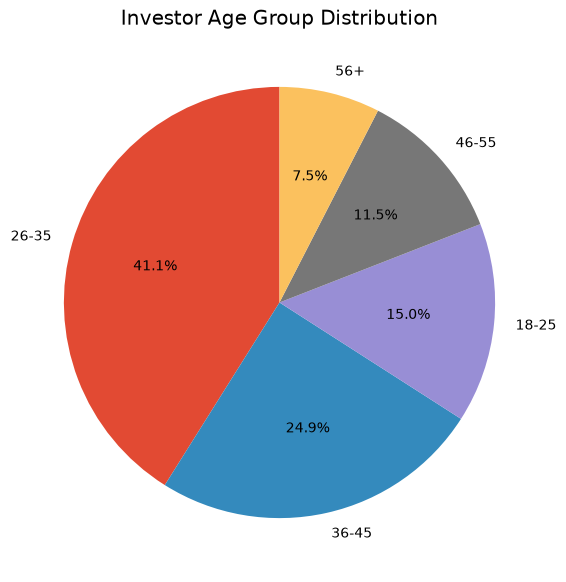

Chart 5A saved successfully!


In [14]:
# Chart 5A - Age Group Distribution

import matplotlib.pyplot as plt

age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    "charts/Chart5_Age_Group_Pie.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart 5A saved successfully!")

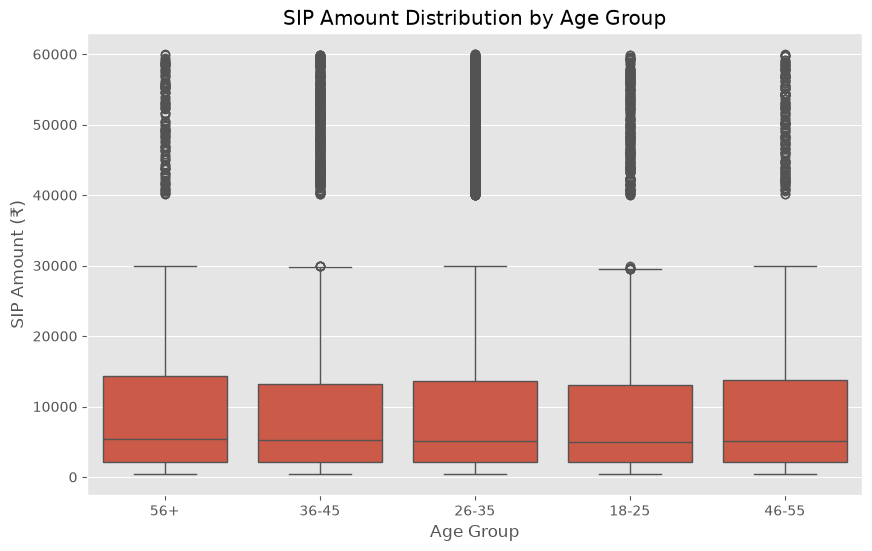

Chart 5B saved successfully!


In [15]:
# Chart 5B - SIP Amount Box Plot

import seaborn as sns
import matplotlib.pyplot as plt

# Filter only SIP transactions
sip_transactions = transactions[
    transactions["transaction_type"] == "Sip"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.savefig(
    "charts/Chart6_SIP_Boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart 5B saved successfully!")

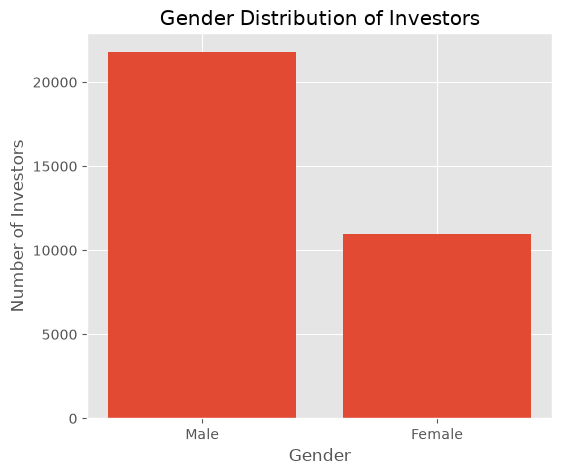

Chart 5C saved successfully!


In [16]:
# Chart 5C - Gender Distribution

gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(
    gender_counts.index,
    gender_counts.values
)

plt.title("Gender Distribution of Investors")
plt.xlabel("Gender")
plt.ylabel("Number of Investors")

plt.savefig(
    "charts/Chart7_Gender_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart 5C saved successfully!")

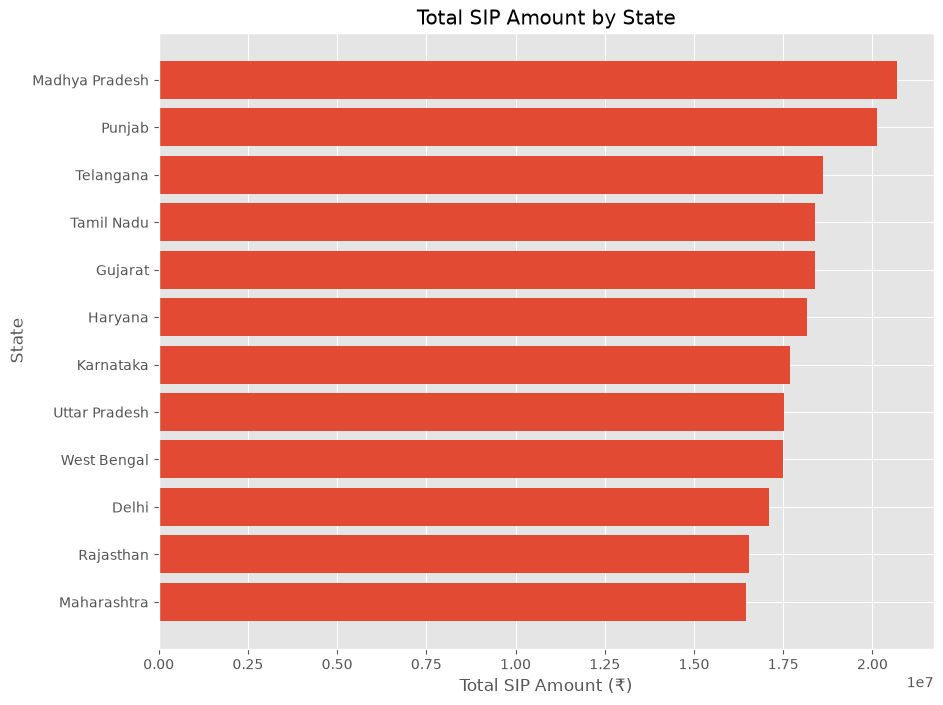

Chart 6A saved successfully!


In [17]:
# Chart 6A - SIP Amount by State

import matplotlib.pyplot as plt

# Filter only SIP transactions
sip_state = transactions[
    transactions["transaction_type"] == "Sip"
]

# Sum SIP amount by state
state_amount = sip_state.groupby("state")["amount_inr"].sum().sort_values()

plt.figure(figsize=(10,8))

plt.barh(
    state_amount.index,
    state_amount.values
)

plt.title("Total SIP Amount by State")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.savefig(
    "charts/Chart8_State_SIP.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart 6A saved successfully!")

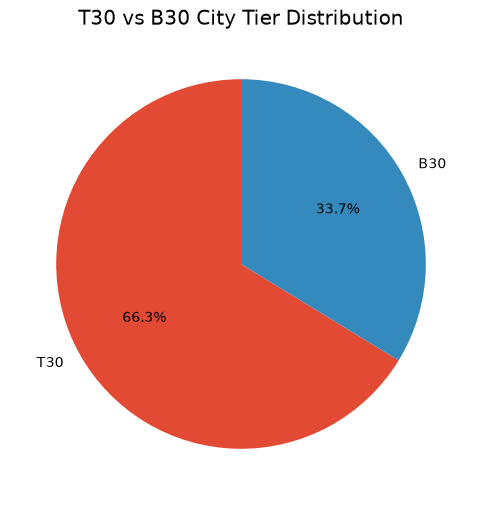

Chart 6B saved successfully!


In [18]:
# Chart 6B - T30 vs B30 City Tier

city_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    city_counts,
    labels=city_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 City Tier Distribution")

plt.savefig(
    "charts/Chart9_City_Tier_Pie.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart 6B saved successfully!")

In [19]:
print(folio.columns)

print("\nShape:")
print(folio.shape)

print("\nFirst 5 rows:")
print(folio.head())

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

Shape:
(21, 6)

First 5 rows:
     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  


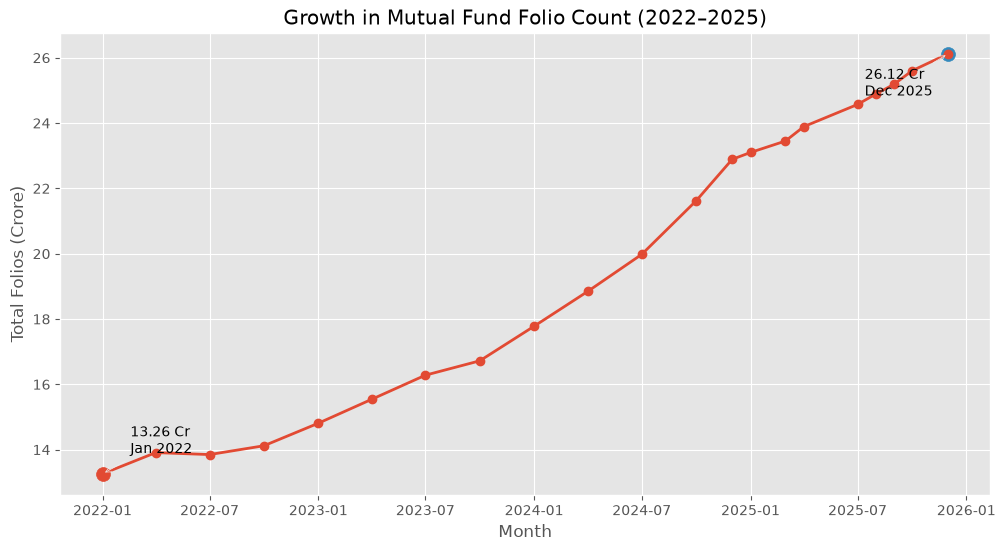

Chart 10 saved successfully!


In [20]:
# Chart 10 - Folio Count Growth

import matplotlib.pyplot as plt

# Convert month column to datetime
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2
)

# Highlight start point
plt.scatter(
    folio["month"].iloc[0],
    folio["total_folios_crore"].iloc[0],
    s=100
)

plt.annotate(
    "13.26 Cr\nJan 2022",
    xy=(folio["month"].iloc[0], folio["total_folios_crore"].iloc[0]),
    xytext=(20,15),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

# Highlight last point
plt.scatter(
    folio["month"].iloc[-1],
    folio["total_folios_crore"].iloc[-1],
    s=100
)

plt.annotate(
    "26.12 Cr\nDec 2025",
    xy=(folio["month"].iloc[-1], folio["total_folios_crore"].iloc[-1]),
    xytext=(-60,-30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title("Growth in Mutual Fund Folio Count (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.savefig(
    "charts/Chart10_Folio_Growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart 10 saved successfully!")

In [21]:
print(portfolio.columns)
print("\n")
print(portfolio.head())

print("\n=====================\n")

print(nav_history.columns)
print("\n")
print(nav_history.head())

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  


Index(['amfi_code', 'date'

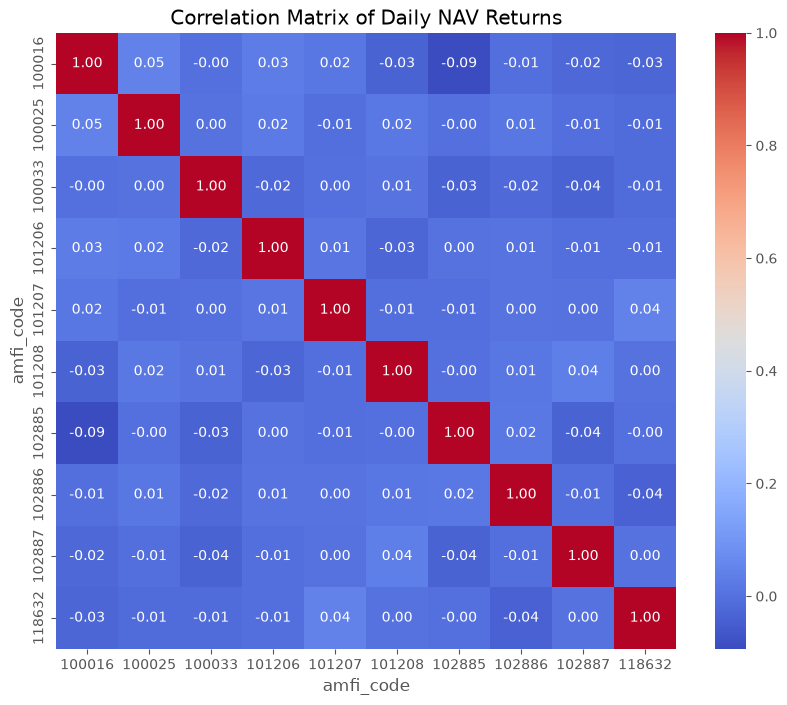

Chart 11 saved successfully!


In [22]:
# Chart 11 - NAV Return Correlation Matrix

import seaborn as sns
import matplotlib.pyplot as plt

# Convert date column
nav_history["date"] = pd.to_datetime(nav_history["date"])

# Select first 10 AMFI codes
selected_codes = nav_history["amfi_code"].unique()[:10]

# Filter data
selected_nav = nav_history[
    nav_history["amfi_code"].isin(selected_codes)
]

# Pivot data
pivot_nav = selected_nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

# Calculate daily returns
returns = pivot_nav.pct_change().dropna()

# Correlation matrix
corr = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Daily NAV Returns")

plt.savefig(
    "charts/Chart11_NAV_Correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart 11 saved successfully!")

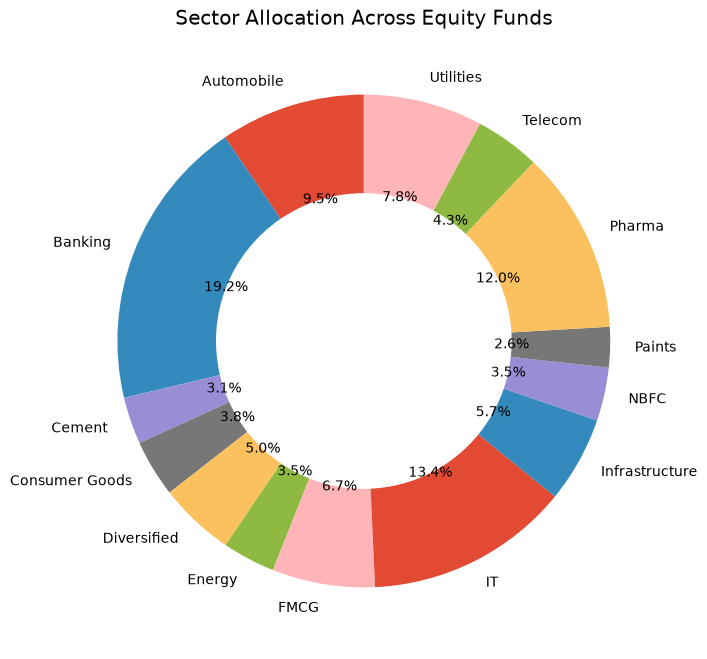

Chart 12 saved successfully!


In [23]:
# Chart 12 - Sector Allocation Donut

import matplotlib.pyplot as plt

# Aggregate sector weights
sector_data = portfolio.groupby("sector")["weight_pct"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation Across Equity Funds")

plt.savefig(
    "charts/Chart12_Sector_Donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart 12 saved successfully!")

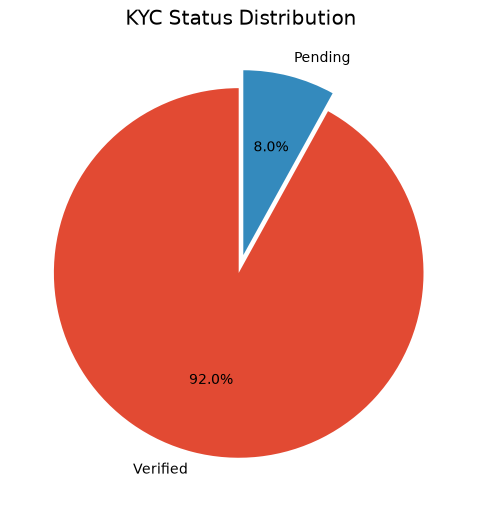

Chart 13 saved successfully!


In [27]:
# Chart 16 - KYC Status Distribution

import matplotlib.pyplot as plt

kyc_counts = transactions["kyc_status"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    kyc_counts,
    labels=kyc_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=(0.05, 0.05)
)

plt.title("KYC Status Distribution")

plt.savefig(
    "charts/Chart16_KYC_Status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart 13 saved successfully!")

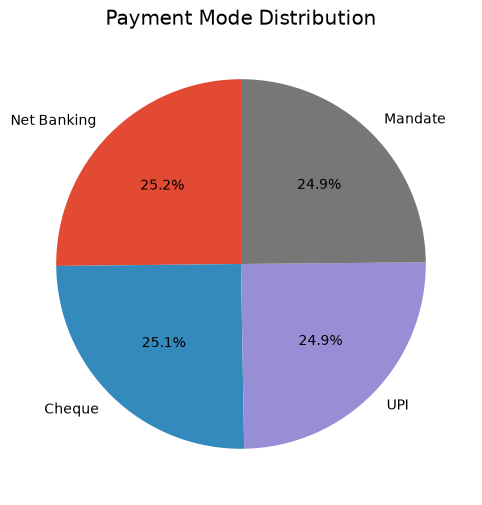

Chart 14 saved successfully!


In [25]:
# Chart 14 - Payment Mode Distribution

payment_counts = transactions["payment_mode"].value_counts()

plt.figure(figsize=(8,6))

plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Payment Mode Distribution")

plt.savefig(
    "charts/Chart14_Payment_Mode.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart 14 saved successfully!")

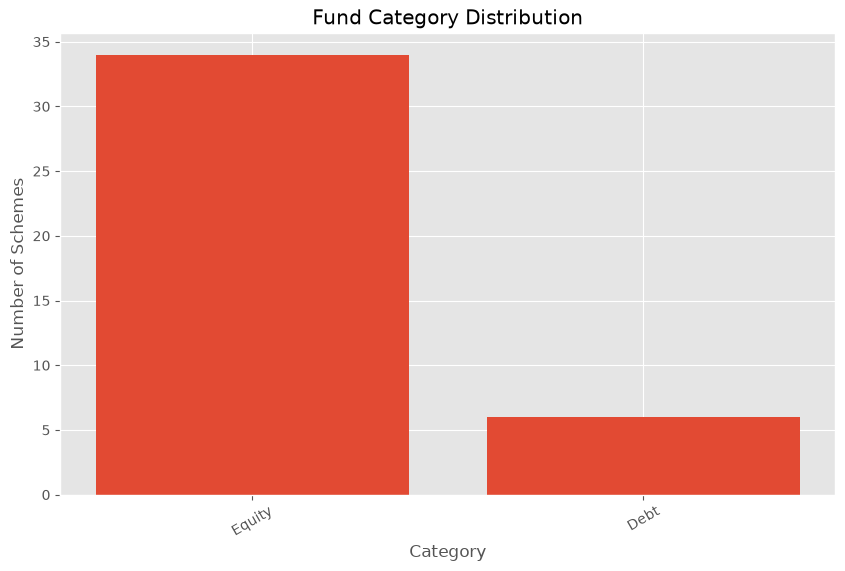

Chart 15 saved successfully!


In [26]:
# Chart 15 - Fund Category Distribution

category_counts = fund_master["category"].value_counts()

plt.figure(figsize=(10,6))

plt.bar(
    category_counts.index,
    category_counts.values
)

plt.xticks(rotation=30)

plt.title("Fund Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Schemes")

plt.savefig(
    "charts/Chart15_Fund_Category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart 15 saved successfully!")

# EDA Findings

1. Daily NAV values showed an overall upward trend from 2022 to 2025, indicating long-term growth across most mutual fund schemes.

2. SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM) among all fund houses.

3. Monthly SIP inflows steadily increased and reached an all-time high of ₹31,002 crore in December 2025.

4. Flexi Cap and Mid Cap categories attracted higher net inflows compared to several other fund categories.

5. Investors aged 26–35 formed one of the largest investor groups.

6. SIP investment amounts varied across different age groups, with some age groups showing higher investment ranges.

7. Male investors slightly outnumbered female investors in the transaction dataset.

8. T30 cities contributed a larger share of mutual fund transactions compared to B30 cities.

9. Total mutual fund folio count increased significantly from 13.26 crore in January 2022 to 26.12 crore in December 2025.

10. Sector allocation showed diversification across Banking, Pharma, Utilities, IT, FMCG, and other sectors.